#**Import Library**

In [240]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#**Business Understanding**

##**Business Objective**

Dataset Salary_Data

Data ini merupakan sebuah data gaji pekerja yang diambil dari berbagai sumber seperti survey, situs lowongan kerja, dan sumber publik lainnya. Tujuan dari analisis ini adalah untuk memahami faktor-faktor apa saja yang dapat memengaruhi gaji seorang pekerja.

Di dalam dataset ini terdapat 6704 baris dan 6 kolom.

##**Assess Situation**

Kondisi dari dataset ini memiliki empat variabel (umur, tingkat pendidikan terakhir, posisi jabatan, dan pengalaman) yang dapat memengaruhi besar gaji yang didapatkan oleh sebuah pekerja.

Karena dataset ini mencakup variabel yang banyak, maka butuh pemahaman dan proses analisis yang lebih dalam.

##**Analytic Goals & Project Plan**

Untuk mengatasi masalah berikut, di dalam dataset ini akan dilakukan:

*   Analisis faktor-faktor penentu gaji
*   Penentuan variabel yang paling dominan dalam memengaruhi gaji
*   Menyajikan data dalam bentuk visualisasi

#**Data Understanding**

##**Memuat Dataset**

In [241]:
file = "/content/drive/MyDrive/AVD praktikum1/Salary_Data.csv"
df = pd.read_csv(file)
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


##**Struktur Data (Informasi Lanjutan)**

In [242]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [243]:
df.tail()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0
6703,26.0,Female,High School,Sales Executive,1.0,35000.0


In [244]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [245]:
df.shape

(6704, 6)

##**Informasi Statistik Deskriptif**

In [246]:
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


*Count* itu menghitung baris. Karena total seluruh baris 6704, ketiga kolom 'Age', 'Years of Experience', dan 'Salary' memiliki missing values.

*Mean* menghitung rata-rata (total semua data/jumlah data).

*25%, 50%,* dan *75%* menghitung nilai kuartil 1, kuartil 2, kuartil 3.

*Min* merupakan nilai terkecil dari kolom data, dan *Max* merupakan nilai terbesar.

In [247]:
df.value_counts()

Age   Gender  Education Level    Job Title                  Years of Experience  Salary  
24.0  Female  High School        Receptionist               0.0                  25000.0     45
32.0  Male    Bachelor's Degree  Product Manager            7.0                  120000.0    45
27.0  Male    Bachelor's Degree  Software Engineer          3.0                  80000.0     45
32.0  Male    Bachelor's         Software Engineer          8.0                  190000.0    39
33.0  Female  Master's           Product Manager            11.0                 198000.0    38
                                                                                             ..
23.0  Male    High School        Sales Executive            1.0                  35000.0      1
              PhD                Software Engineer Manager  1.0                  579.0        1
54.0  Male    PhD                Software Engineer Manager  28.0                 182013.0     1
23.0  Male    Bachelor's         Data Analyst               1.0                  92000.0      1
                                                                                 95000.0      1
Name: count, Length: 1787, dtype: int64

In [248]:
df.mean(numeric_only=True)

,0
Age,33.620859
Years of Experience,8.094687
Salary,115326.964771


In [249]:
df.median(numeric_only=True)

,0
Age,32.0
Years of Experience,7.0
Salary,115000.0


In [250]:
df.std(numeric_only=True)

,0
Age,7.614633
Years of Experience,6.059003
Salary,52786.183911


In [251]:
df.corr(numeric_only=True)

,Age,Years of Experience,Salary
Age,1.000000,0.937655,0.728053
Years of Experience,0.937655,1.000000,0.808969
Salary,0.728053,0.808969,1.000000


##**Struktur Kode**

###**Tipe Data Tiap Kolom**

In [252]:
df.dtypes

,0
Age,float64
Gender,object
Education Level,object
Job Title,object
Years of Experience,float64
Salary,float64


###**Inconsistent Values**

In [253]:
print(df['Age'].unique())

[32. 28. 45. 36. 52. 29. 42. 31. 26. 38. 48. 35. 40. 27. 44. 33. 39. 25.
 51. 34. 47. 30. 41. 37. 24. 43. 50. 46. 49. 23. 53. nan 61. 57. 62. 55.
 56. 54. 60. 58. 22. 21.]


In [254]:
print(df['Gender'].unique())

['Male' 'Female' nan 'Other']


In [255]:
print(df['Education Level'].unique())

["Bachelor's" "Master's" 'PhD' nan "Bachelor's Degree" "Master's Degree"
 'High School' 'phD']


In [256]:
print(df['Job Title'].unique())

['Software Engineer' 'Data Analyst' 'Senior Manager' 'Sales Associate'
 'Director' 'Marketing Analyst' 'Product Manager' 'Sales Manager'
 'Marketing Coordinator' 'Senior Scientist' 'Software Developer'
 'HR Manager' 'Financial Analyst' 'Project Manager' 'Customer Service Rep'
 'Operations Manager' 'Marketing Manager' 'Senior Engineer'
 'Data Entry Clerk' 'Sales Director' 'Business Analyst' 'VP of Operations'
 'IT Support' 'Recruiter' 'Financial Manager' 'Social Media Specialist'
 'Software Manager' 'Junior Developer' 'Senior Consultant'
 'Product Designer' 'CEO' 'Accountant' 'Data Scientist'
 'Marketing Specialist' 'Technical Writer' 'HR Generalist'
 'Project Engineer' 'Customer Success Rep' 'Sales Executive' 'UX Designer'
 'Operations Director' 'Network Engineer' 'Administrative Assistant'
 'Strategy Consultant' 'Copywriter' 'Account Manager'
 'Director of Marketing' 'Help Desk Analyst' 'Customer Service Manager'
 'Business Intelligence Analyst' 'Event Coordinator' 'VP of Finance'
 'G

In [257]:
print(df['Years of Experience'].unique())

[ 5.   3.  15.   7.  20.   2.  12.   4.   1.  10.  18.   6.  14.  16.
  0.  22.  19.   9.  13.  11.  25.  21.   8.  17.  23.  24.   0.5  1.5
  nan 31.  30.  28.  33.  27.  34.  29.  26.  32. ]


In [258]:
print(df['Salary'].unique())

[ 90000.  65000. 150000.  60000. 200000.  55000. 120000.  80000.  45000.
 110000.  75000. 140000. 130000.  40000. 125000. 115000.  35000. 180000.
 190000.  50000. 250000. 170000. 160000.  85000.  95000. 105000.  70000.
 100000.  30000. 135000. 220000. 175000. 185000.     nan 145000. 155000.
    350. 195000. 198000. 196000. 193000.  92000. 165000. 162000. 197000.
 142000. 182000. 210000.    550. 122485. 169159. 187081. 166109.  78354.
  90249. 132720. 161568. 127346. 120177.  69032. 101332. 121450. 166375.
 185119. 149217. 166512. 186963.  75072. 163398. 103947. 179180. 175966.
 190004. 152039.  76742. 191790. 139398.  95845. 160976. 126753. 161393.
 139817. 181714. 114776. 105725.  52731. 106492.  73895. 119836.  99747.
 168287. 115920. 128078.  51265. 165919. 188651.  55538. 193964. 104702.
 172955. 138032.  82683. 155414. 154207. 107895. 148446. 102859. 138662.
 181699. 188232.  51832. 188484. 138286. 181132.  73938. 119224. 101186.
 142360. 151315. 181021. 134641. 173851. 104127. 17

Setelah melakukan pengecekan, dapat disimpulkan bahwa banyak kolom yang memiliki inconsistent values. Seperti kolom 'Age', 'Gender', 'Years of Experience', dan 'Salary' yang memiliki nilai nan, dan juga kolom 'Education Level' yang memiliki nilai nan dan data duplikat ("PhD" dan "phD", dll).

###**Missing Values**

In [259]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Age,0.029833
Gender,0.029833
Education Level,0.044749
Job Title,0.029833
Years of Experience,0.044749
Salary,0.074582


Dari hasil pengecekan, dapat diambil insight bahwa masih ada terdapat missing values di keenam kolom data.

Kolom 'Age', 'Gender', dan 'Job Title' memiliki persenan missing values yang sama (0,029%), begitupun juga kolom 'Education Level' dan 'Years of Experience' (0,044%). Sedangkan kolom yang memiliki missing values yang terbanyak adalah kolom 'Salary', sebanyak 0,074%.

###**Duplicated Values**

In [260]:
df[df.duplicated()]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
195,28.0,Male,Bachelor's,Junior Business Analyst,2.0,40000.0
250,30.0,Female,Bachelor's,Junior Marketing Coordinator,2.0,40000.0
251,38.0,Male,Master's,Senior IT Consultant,9.0,110000.0
252,45.0,Female,PhD,Senior Product Designer,15.0,150000.0
253,28.0,Male,Bachelor's,Junior Business Development Associate,2.0,40000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


Setelah hasil pengecekan, dapat disimpulkan bahwa dari 6704 baris data, ada terdapat 4912 baris data yang terduplikat.

###**Outliers Values**

In [261]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Age,1.834726
Years of Experience,1.118735
Salary,0.000000


Dari hasil pengecekan, dapat disimpulkan bahwa pada kolom 'Age' dan 'Years of Experience' masih terdapat nilai outliers sebesar 1%. Sedangkan kolom 'Salary' tidak terdapat nilai outliers.


#**EDA**

##**Comparison (Perbandingan)**

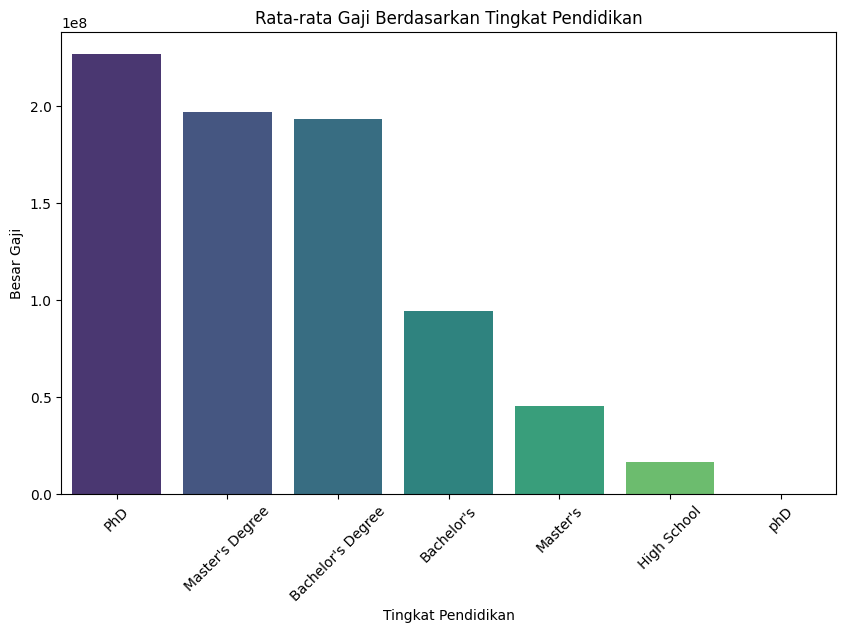

In [262]:
rata_gaji = df.groupby('Education Level')['Salary'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=rata_gaji.index, y=rata_gaji.values, palette='viridis', hue=rata_gaji.index, legend=False)
plt.title('Rata-rata Gaji Berdasarkan Tingkat Pendidikan')
plt.xlabel('Tingkat Pendidikan')
plt.ylabel('Besar Gaji')
plt.xticks(rotation=45)
plt.show()

Output visual yang ditampilkan untuk perbandingan rata-rata gaji berdasarkan tingkat pendidikan berbentuk sebuah bar chart. Variabel X adalah Tingkat Pendidikan dan Variabel Y adalah Besar Gaji.

Dapat dilihat dari gambar bahwa PhD (S3) memiliki rata-rata gaji tertinggi dibandingkan tingkat pendidikan lainnya, yang kemudian disusul oleh Master’s Degree (S2) dan Bachelor’s Degree (S1) dengan nilai yang berdekatan. Sementara itu, tingkat pendidikan High School (SMA) memiliki rata-rata gaji paling rendah.

Secara umum, grafik ini menunjukkan adanya kecenderungan bahwa semakin tinggi tingkat pendidikan, semakin tinggi pula rata-rata gaji yang diterima.

Namun, di bar chart juga terdapat kategori pendidikan yang terduplikat ("PhD" dan "phD", "Master's Degree" dan "Master's", "Bachelor's Degree" dan "Bachelor's"), maka sebaiknya dilakukan pembersihan data agar nilai perbandingan lebih akurat.

##**Composition (Komposisi)**

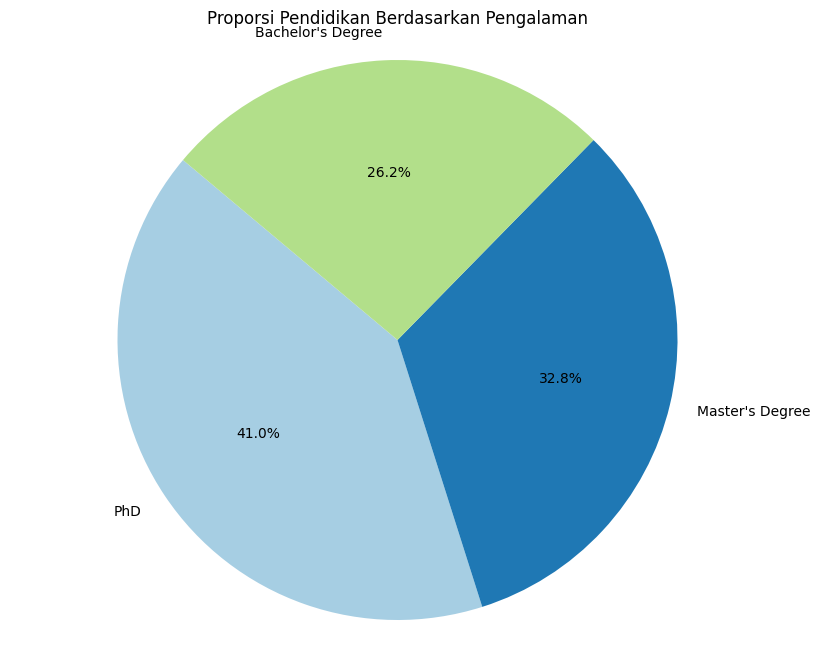

In [263]:
education_by_experience = df.groupby('Education Level')['Years of Experience'].sum().sort_values(ascending=False)
education_by_experience_top3 = education_by_experience.head(3)

plt.figure(figsize=(10, 8))
education_by_experience_top3.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Proporsi Pendidikan Berdasarkan Pengalaman')
plt.ylabel('')
plt.axis('equal')
plt.show()

Output visual yang ditampilkan untuk menggambarkan proporsi kontribusi pengalaman kerja dari masing-masing tingkat pendidikan berbentuk sebuah pie chart.

Dapat dilihat bahwa individu dengan pendidikan PhD memiliki rata-rata pengalaman kerja yang lebih lama/banyak dibandingkan Master's atau Bachelor's. Hal ini kemungkinan karena posisi yang mensyaratkan pendidikan tinggi biasanya ditempati oleh karyawan senior.

##**Distribution (Distribusi)**

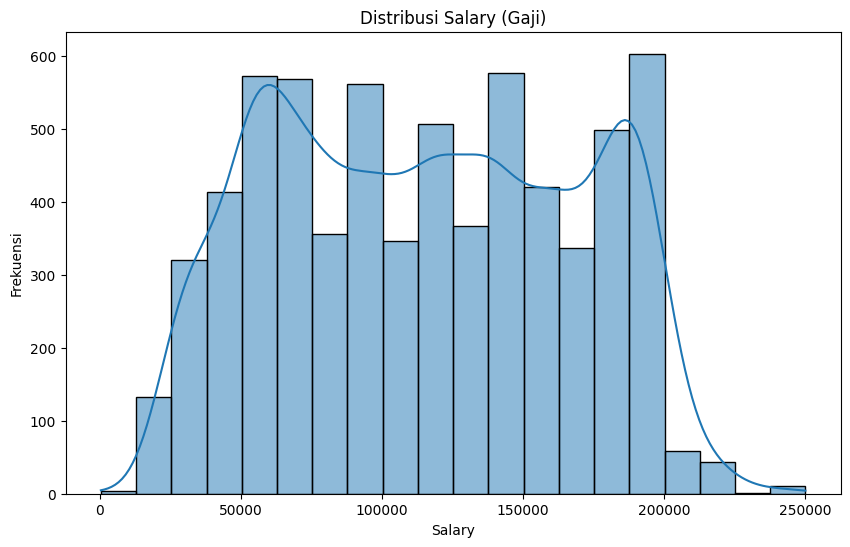

In [264]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Salary'], bins=20, kde=True)
plt.title('Distribusi Salary (Gaji)')
plt.xlabel('Salary')
plt.ylabel('Frekuensi')
plt.show()

Output visual yang ditampilkan untuk menggambarkan distribusi gaji berbentuk sebuah graph histogram. Variabel X adalah Gaji dan variabel Y adalah Frekuensi.

Dapat terlihat dari visual graphnya, sebagian besar karyawan memiliki gaji pada kisaran menengah, dengan beberapa nilai tinggi yang menunjukkan adanya posisi dengan kompensasi lebih besar. Distribusi cenderung sedikit skew ke kiri karena adanya gaji tinggi sebagai outlier.

##**Relationship (Hubungan)**

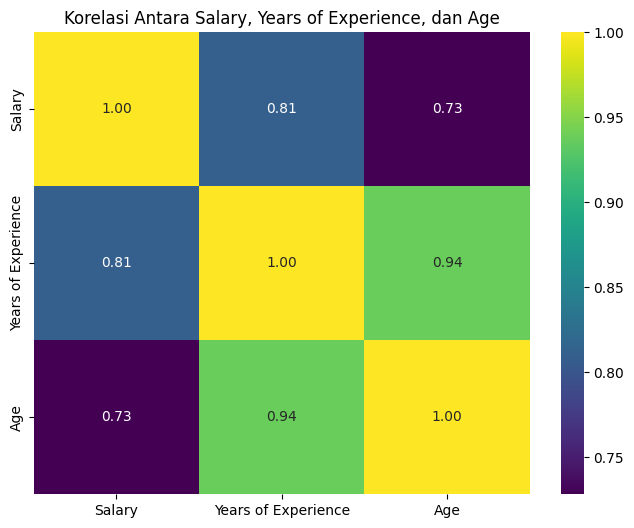

In [265]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['Salary', 'Years of Experience', 'Age']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi Antara Salary, Years of Experience, dan Age')
plt.show()

Output visual yang ditampilkan untuk menggambarkan hubungan antara gaji, pengalaman kerja, dan umur berbentuk sebuah Heatmap.

Terdapat korelasi positif yang kuat antara Salary dan Years of Experience (0.81), menunjukkan bahwa pengalaman kerja merupakan faktor utama yang memengaruhi kenaikan gaji. Sementara itu, usia juga memiliki hubungan positif dengan gaji (0.73), namun pengaruhnya lebih kecil dibandingkan pengalaman kerja.

Korelasi antara usia dan pengalaman kerja sangat tinggi (0.94). Kedua variabel ini saling berkaitan karena bertambahnya usia biasanya diikuti peningkatan pengalaman kerja.

#**Data Preparation**

##**Inconsistent Values**

In [266]:
df['Job Title'] = df['Job Title'].str.title()
print(df['Job Title'].unique())

['Software Engineer' 'Data Analyst' 'Senior Manager' 'Sales Associate'
 'Director' 'Marketing Analyst' 'Product Manager' 'Sales Manager'
 'Marketing Coordinator' 'Senior Scientist' 'Software Developer'
 'Hr Manager' 'Financial Analyst' 'Project Manager' 'Customer Service Rep'
 'Operations Manager' 'Marketing Manager' 'Senior Engineer'
 'Data Entry Clerk' 'Sales Director' 'Business Analyst' 'Vp Of Operations'
 'It Support' 'Recruiter' 'Financial Manager' 'Social Media Specialist'
 'Software Manager' 'Junior Developer' 'Senior Consultant'
 'Product Designer' 'Ceo' 'Accountant' 'Data Scientist'
 'Marketing Specialist' 'Technical Writer' 'Hr Generalist'
 'Project Engineer' 'Customer Success Rep' 'Sales Executive' 'Ux Designer'
 'Operations Director' 'Network Engineer' 'Administrative Assistant'
 'Strategy Consultant' 'Copywriter' 'Account Manager'
 'Director Of Marketing' 'Help Desk Analyst' 'Customer Service Manager'
 'Business Intelligence Analyst' 'Event Coordinator' 'Vp Of Finance'
 'G

In [267]:
df['Education Level'] = df['Education Level'].replace({
      "Bachelor's": "Bachelor's",
          "Bachelor's Degree": "Bachelor's",
              "Master's": "Master's",
                  "Master's Degree": "Master's",
                      "phD": "PhD"
                      })
for col in ['Education Level']:
      print(df[col].unique())

["Bachelor's" "Master's" 'PhD' nan 'High School']


##**Missing Values**

In [268]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Age,0.029833
Gender,0.029833
Education Level,0.044749
Job Title,0.029833
Years of Experience,0.044749
Salary,0.074582


Karena data yang hilang kurang dari 70%, maka data dapat diimputasi.

In [269]:
df['Age'] = df['Age'].fillna(df['Age'].dropna().mean())

In [270]:
df['Gender'] = df['Gender'].fillna(df['Gender'].dropna().mode()[0])

In [271]:
df['Education Level'] = df['Education Level'].fillna(df['Education Level'].dropna().mode()[0])

In [272]:
df['Job Title'] = df['Job Title'].fillna(df['Job Title'].dropna().mode()[0])

In [273]:
df['Years of Experience'] = df['Years of Experience'].fillna(df['Years of Experience'].dropna().mean())

In [274]:
df['Salary'] = df['Salary'].fillna(df['Salary'].dropna().mean())

Kolom 'Education Level', 'Job Title', dan 'Years of Experience' menggunakan tipe data string. Oleh karena itu, penanganan missing values dilakukan menggunakan metode imputasi modus (nilai yang sering muncul). Sedangkan tipe data yang numerik menggunakan metode imputasi mean (nilai rata-rata).

In [275]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Age,0.0
Gender,0.0
Education Level,0.0
Job Title,0.0
Years of Experience,0.0
Salary,0.0


##**Duplicated Values**

In [276]:
df[df.duplicated()]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
195,28.0,Male,Bachelor's,Junior Business Analyst,2.0,40000.0
250,30.0,Female,Bachelor's,Junior Marketing Coordinator,2.0,40000.0
251,38.0,Male,Master's,Senior It Consultant,9.0,110000.0
252,45.0,Female,PhD,Senior Product Designer,15.0,150000.0
253,28.0,Male,Bachelor's,Junior Business Development Associate,2.0,40000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director Of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's,Marketing Manager,14.0,140000.0


Karena data yang terduplikasi tidak relevan, maka harus dihapus.

In [277]:
df = df.drop_duplicates()

In [278]:
df[df.duplicated()]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary


##**Outliers Values**

In [279]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Age,0.335008
Years of Experience,1.228364
Salary,0.000000


Data outliers yang kurang dari 10% dapat ditanganin dengan cara dihapus.

In [280]:
columns_to_impute = ["Age", "Years of Experience"]

for col in columns_to_impute:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menggunakan .loc[] agar tidak muncul SettingWithCopyWarning
    df.loc[:, col] = df[col].clip(lower=lower_bound, upper=upper_bound)

In [291]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Age,0.0
Years of Experience,0.0
Salary,0.0


#**Data Construct**

Kolom baru yang saya buat adalah 'Salary Category', yang berfungsi untuk mengkategorikan gaji dari *minimum wage*, *average wage*, dan *high wage*. Pengelompokan rentang gaji ini bertujuan untuk mempermudah proses analisis, sehingga pola perbedaan tingkat pendapatan dapat lebih mudah diidentifikasi dan dibandingkan.

In [282]:
def categorize_salary(Salary):
    if Salary <= 60000:
        return 'Minimum Wage'
    elif Salary <= 170000:
        return 'Average Wage'
    else:
        return 'High Wage'

df['Salary Category'] = df['Salary'].apply(categorize_salary)

/tmp/ipykernel_1277/3980405783.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Salary Category'] = df['Salary'].apply(categorize_salary)


In [283]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Salary Category
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,Average Wage
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,Average Wage
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,Average Wage
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,Minimum Wage
4,52.0,Male,Master's,Director,20.0,200000.0,High Wage


#**Data Reduction**

Saya tidak melakukan tahap reduksi data pada dataset ini, karena menurut saya, kolom-kolom yang ada sudah cukup relevan dan mendukung tujuan analisis.

In [284]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Salary Category
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,Average Wage
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,Average Wage
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,Average Wage
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,Minimum Wage
4,52.0,Male,Master's,Director,20.0,200000.0,High Wage


#**Visualisasi Data**

##**Bar Chart**

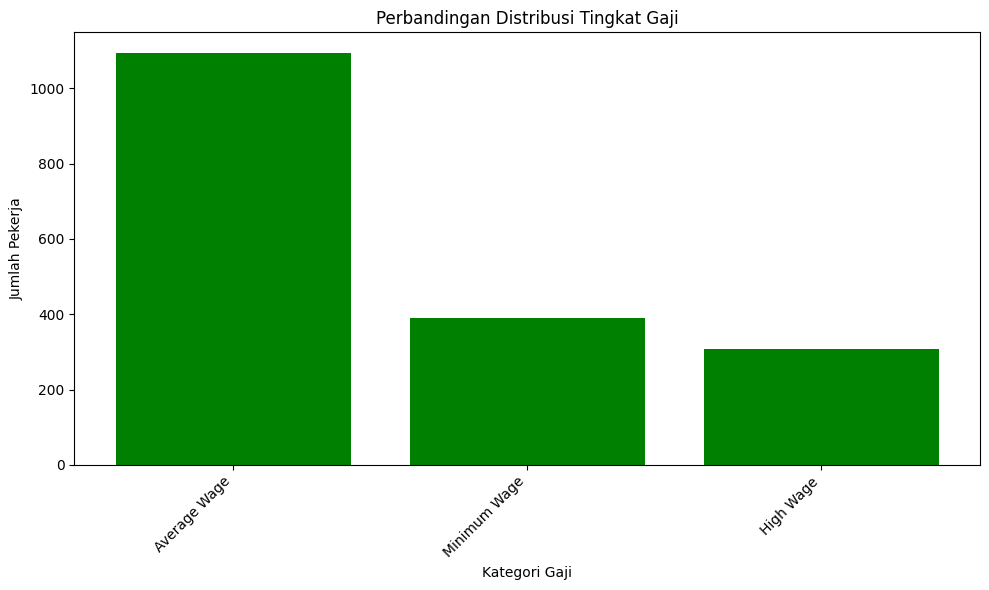

In [286]:
VARIABEL = df['Salary Category'].value_counts().head(5).sort_values(ascending=False) # head() jumlah yang mau ditampilkan & Urutan

plt.figure(figsize=(10, 6)) # Ukuran
plt.bar(VARIABEL.index, VARIABEL.values, color='green') # color warna
plt.xlabel('Kategori Gaji') # keterangan X label
plt.ylabel('Jumlah Pekerja') # keterangan y label
plt.title('Perbandingan Distribusi Tingkat Gaji') # Judul
plt.xticks(rotation=45, ha='right') # rotasi teks
plt.tight_layout()
plt.show()

Berdasarkan grafik bar di atas, kategori Average Wage memiliki jumlah tertinggi dibandingkan kategori lainnya, menunjukkan bahwa mayoritas pekerja memperoleh gaji menengah. Kategori Minimum Wage menunjukkan masih adanya pekerja yang menerima upah minimum/UMR, sedangkan kategori High Wage memiliki jumlah paling sedikit, menandakan hanya sebagian kecil pekerja memperoleh gaji tertinggi.

Distribusi ini memperlihatkan bahwa sebagian besar pekerja berada pada tingkat menengah, sementara pekerja dengan gaji minimum maupun maksimum jumlahnya relatif sedikit. Oleh karena itu, diperlukan langkah-langkah seperti program pelatihan teknis dan soft skill, kesempatan promosi atau rotasi jabatan, serta pemberian insentif kinerja untuk mendorong pekerja berupah minimum meningkatkan pendapatan dan pekerja menengah mencapai gaji tertinggi.

##**Pie Chart**

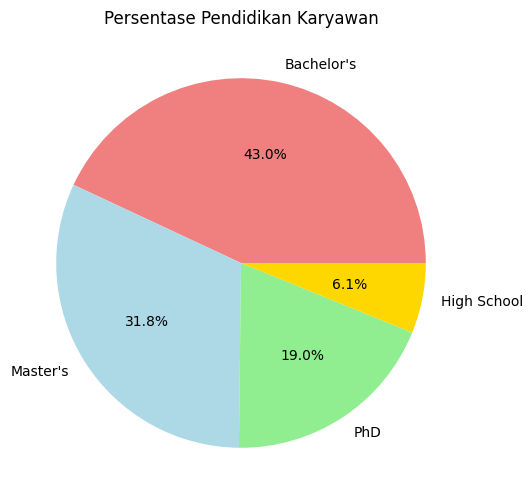

In [287]:
plt.figure(figsize=(10, 6)) # ukuran
plt.pie(df['Education Level'].value_counts(), labels=df['Education Level'].value_counts().index, autopct='%1.1f%%', colors=['lightcoral', 'lightblue', 'lightgreen', 'gold']) # colors (warna)
plt.title('Persentase Pendidikan Karyawan') # Judul
plt.show()

Berdasarkan diagram pie, terlihat bahwa mayoritas karyawan memiliki tingkat pendidikan yang tinggi. Sebagian besar karyawan berpendidikan Bachelor's (S1) sebesar 43%, diikuti oleh Master's (S2) sebesar 31,8%, dan PhD (S3) sebesar 19%, sedangkan karyawan dengan pendidikan High School (SMA) hanya 6,1%. Hal ini menunjukkan bahwa perusahaan cenderung merekrut tenaga kerja dengan kualifikasi pendidikan minimal S1 serta beroperasi pada bidang yang menuntut kemampuan analitis dan keahlian profesional.

Berdasarkan kondisi tersebut, perusahaan dapat memanfaatkan potensi sumber daya manusia yang berpendidikan tinggi melalui program pengembangan kepemimpinan, peningkatan keterampilan (upskilling), serta inovasi atau riset untuk mendorong produktivitas dan kreativitas karyawan. Strategi pengembangan yang tepat juga dapat mengoptimalkan kompetensi karyawan dalam mendukung pertumbuhan dan meningkatkan daya saing organisasi.

##**Line Chart**

In [288]:
df.dtypes

,0
Age,float64
Gender,object
Education Level,object
Job Title,object
Years of Experience,float64
Salary,float64
Salary Category,object


Karena dataset ini tidak memiliki kolom dengan tipe data datetime atau informasi waktu, maka analisis tren tidak dapat dilakukan.

##**Histogram**

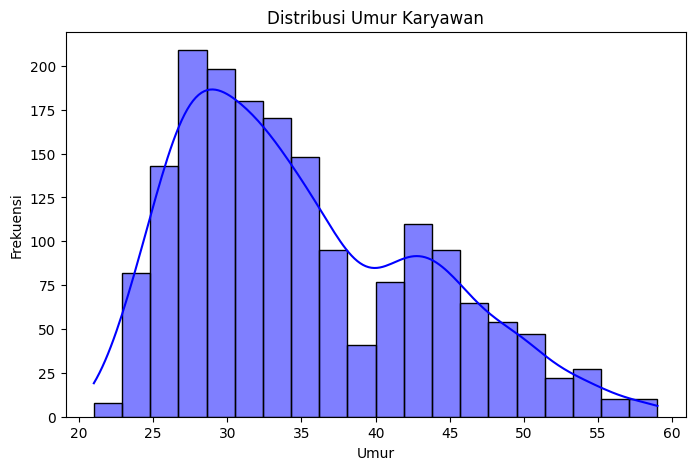

In [289]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=20, kde=True, color='blue')
plt.title('Distribusi Umur Karyawan')
plt.xlabel('Umur')
plt.ylabel('Frekuensi')
plt.show()

Dapat dilihat dari grafik distribusi umur karyawan bahwa distribusi data cenderung condong ke kiri, yang menunjukkan dominasi karyawan pada rentang usia yang lebih muda. Sebagian besar karyawan berada pada usia 25-35 tahun, yang mencerminkan bahwa tenaga kerja perusahaan didominasi oleh individu pada tahap awal hingga pertengahan karier. Selain itu, terlihat pula kelompok lain pada rentang usia 40-45 tahun yang kemungkinan merepresentasikan karyawan dengan posisi lebih senior atau manajerial. Di sisi lain, jumlah karyawan berusia di atas 50 tahun relatif sedikit, yang dapat mengindikasikan terbatasnya posisi senior dalam struktur organisasi atau adanya pergantian karyawan sebelum mencapai usia tersebut.


Dari pola tersebut, perusahaan dapat mengambil beberapa langkah strategis. Karena mayoritas karyawan berada pada usia produktif yang muda, perusahaan perlu berfokus pada pengembangan karier guna mempersiapkan mereka menjadi calon pemimpin di masa depan. Selain itu, keberadaan karyawan pada kelompok usia yang lebih senior dapat dimanfaatkan melalui program mentoring atau transfer pengetahuan, sehingga pengalaman dan keahlian yang dimiliki dapat diwariskan kepada karyawan yang lebih muda.

##**BoxPlot**

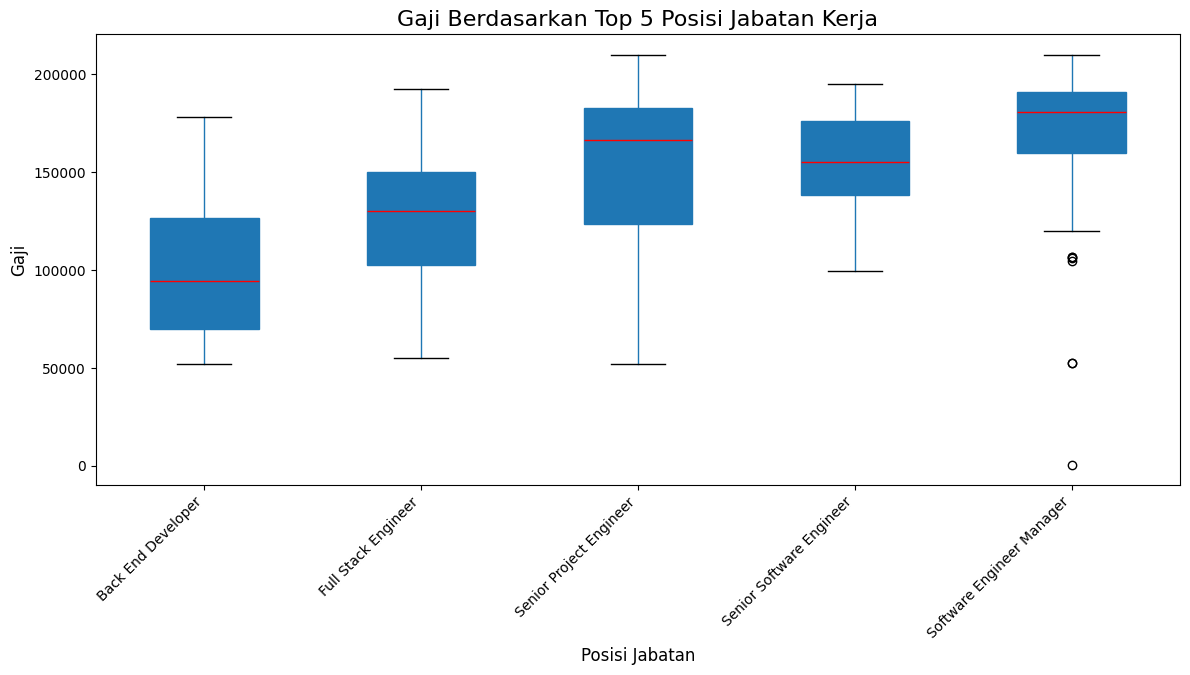

In [290]:
top5jabatan = df['Job Title'].value_counts().head(5).index
df_top5_jabatan = df[df['Job Title'].isin(top5jabatan)]

plt.figure(figsize=(12, 7)) # Ukuran figure
df_top5_jabatan.boxplot(column='Salary', by='Job Title', ax=plt.gca(), grid=False, patch_artist=True, medianprops=dict(color='red'))
plt.title('Gaji Berdasarkan Top 5 Posisi Jabatan Kerja', fontsize=16) # Judul
plt.xlabel('Posisi Jabatan', fontsize=12) # X Keterangan
plt.ylabel('Gaji', fontsize=12) # Y Keterangan
plt.xticks(rotation=45, ha='right')
plt.suptitle('') # Menghilangkan judul default dari boxplot.by
plt.tight_layout()
plt.show()

Berdasarkan diagram boxplot, posisi Software Engineer Manager memiliki median gaji tertinggi dibandingkan posisi lainnya. Namun, pada posisi ini juga terlihat beberapa nilai outlier dengan gaji yang sangat rendah. Nilai tersebut kemungkinan merepresentasikan gaji yang memang lebih kecil pada kondisi tertentu, seperti perbedaan perusahaan atau pengalaman, atau juga bisa menjadi indikasi adanya anomali data atau kesalahan pencatatan.

Posisi Senior Project Engineer dan Senior Software Engineer juga memiliki median gaji yang relatif tinggi, yang menunjukkan bahwa tingkat senioritas berpengaruh signifikan terhadap peningkatan gaji, karena peran tersebut umumnya melibatkan tanggung jawab yang lebih besar serta menuntut pengalaman dan keahlian yang lebih mendalam.

Posisi Senior Project Engineer menunjukkan variasi gaji yang cukup besar, terlihat dari rentang boxplot yang lebar.

Sementara itu, Full Stack Engineer dan Back End Developer memiliki median gaji yang lebih rendah, yang kemungkinan disebabkan oleh lebih banyaknya posisi pada level entry hingga mid-level.

Berdasarkan temuan ini, ketika seseorang naik ke level jabatan yang lebih tinggi atau memiliki tanggung jawab yang lebih besar, maka biasanya gaji atau kompensasi yang diterima juga meningkat. Maka sebaiknya perusahaan membantu meningkatkan kemampuan karyawan, baik dalam hal keterampilan teknis maupun kemampuan kepemimpinan.

##**Scatter Plot**

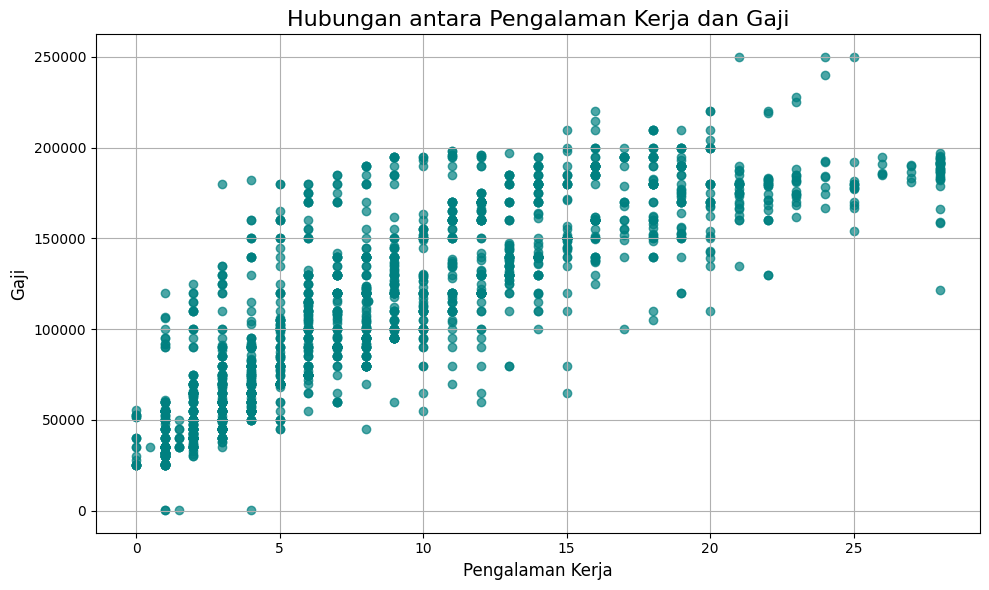

In [308]:
plt.figure(figsize=(10, 6)) # Ukuran
plt.scatter(df['Years of Experience'], df['Salary'], alpha=0.7, color='teal') # Color (Warna)
plt.title('Hubungan antara Pengalaman Kerja dan Gaji', fontsize=16) # Judul
plt.xlabel('Pengalaman Kerja', fontsize=12) # X Keterangan
plt.ylabel('Gaji', fontsize=12) # Y Keterangan
plt.grid(True)
plt.tight_layout()
plt.show()

Dapat dilihat dari scatter plot di atas, bahwa hubungan antara pengalaman kerja dan gaji bersifat positif. Semakin tinggi pengalaman kerja seseorang, maka cenderung semakin tinggi pula gaji yang diperoleh. Hal ini menunjukkan bahwa pengalaman kerja merupakan salah satu faktor penting yang mempengaruhi tingkat gaji dalam suatu pekerjaan. Namun, pada grafik juga terlihat bahwa pada tingkat pengalaman yang sama terdapat variasi gaji yang cukup besar. Sebagai contoh, pada pengalaman kerja sekitar 10 tahun, gaji dapat berada pada rentang yang cukup lebar. Kondisi ini mengindikasikan adanya faktor lain yang turut memengaruhi besaran gaji.

Selain itu, terdapat beberapa titik data yang tampak menyimpang dari pola umum (outlier), seperti individu dengan pengalaman kerja rendah tetapi memiliki gaji tinggi, atau sebaliknya individu dengan pengalaman tinggi namun gajinya relatif lebih rendah dibandingkan yang lain. Perbedaan tersebut dapat disebabkan oleh variasi industri, posisi jabatan, atau kemungkinan adanya ketidaksesuaian data.

Tindakan yang dapat dilakukan oleh perusahaan adalah dengan melakukan evaluasi lebih lanjut terhadap faktor-faktor yang memengaruhi perbedaan gaji, terutama pada karyawan yang memiliki pengalaman kerja rendah tetapi menerima gaji tinggi atau sebaliknya. Perusahaan dapat meninjau kembali struktur dan kebijakan kompensasi untuk memastikan bahwa pemberian gaji telah sesuai dengan pengalaman, tanggung jawab pekerjaan, serta standar industri. Selain itu, perusahaan juga dapat melakukan analisis terhadap peran jabatan, tingkat keterampilan, dan kontribusi karyawan, karena faktor-faktor tersebut dapat menjadi alasan mengapa terdapat perbedaan gaji yang tidak sepenuhnya mengikuti pola pengalaman kerja. Dengan melakukan evaluasi ini, perusahaan dapat memastikan bahwa sistem penggajian tetap adil dan transparan.

##**Heatmap**

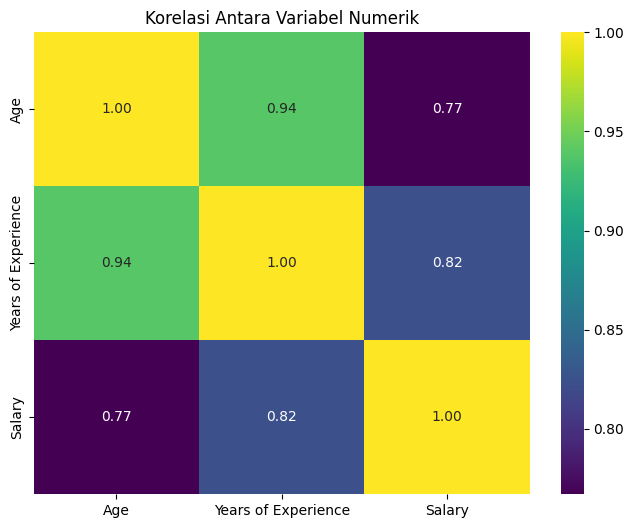

In [309]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['Age', 'Years of Experience', 'Salary']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi Antara Variabel Numerik')
plt.show()

Berdasarkan diagram heatmap, terlihat bahwa Age (usia), Years of Experience (pengalaman kerja), dan Salary (gaji) memiliki hubungan positif yang cukup kuat.

Korelasi antara umur dan pengalaman kerja sebesar 0,94 menunjukkan hubungan yang sangat kuat, yang berarti semakin bertambah usia seseorang, pengalaman kerjanya juga meningkat.

Selanjutnya, pengalaman kerja dan gaji memiliki korelasi sebesar 0,82, yang menunjukkan hubungan positif yang kuat sehingga peningkatan pengalaman cenderung diikuti oleh kenaikan gaji. Sedangkan, umur dan gaji memiliki korelasi sebesar 0,77, yang juga menunjukkan hubungan positif namun dengan kekuatan yang sedikit lebih rendah. Hal ini mengindikasikan bahwa lamanya pengalaman kerja menjadi faktor yang lebih dominan dalam memengaruhi besarnya gaji dibandingkan dengan usia.

Berdasarkan insight tersebut, perusahaan dapat mempertimbangkan untuk menentukan struktur atau rentang gaji yang lebih didasarkan pada pengalaman kerja dibandingkan hanya pada usia karyawan.